# Flat Region Predictions

Loads flat region windows from all folds, fetches sequences from the genome
using the centered coordinates, runs model inference, and plots the first N examples.

In [1]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pyfaidx

sys.path.insert(0, os.path.abspath("/home1/smaruj/ledidi_akita/"))
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from akita.model import SeqNN
from utils.data_utils import from_upper_triu, one_hot_encode_sequence
from utils.insulation_utils import insulation_full

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
SPECIES = "mouse"   # "mouse" or "human"
N_PLOT  = 50        # number of examples to plot

MATRIX_LEN   = 512
NUM_DIAGS    = 2
INSUL_WINDOW = 16
VMIN, VMAX   = -0.6, 0.6
CMAP         = "RdBu_r"

FLAT_REGIONS_DIR = {
    "mouse": "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/analysis/flat_regions/mouse_flat_regions_tsv",
    "human": "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/analysis/flat_regions/human_flat_regions_tsv",
}[SPECIES]

GENOME_FASTA = {
    "mouse": "/project2/fudenber_735/genomes/mm10/mm10.fa",
    "human": "/project2/fudenber_735/genomes/hg38/hg38.fa",
}[SPECIES]

MODEL_PATH = {
    "mouse": "/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth",
    "human": "/home1/smaruj/pytorch_akita/models/finetuned/human/Krietenstein2019_HFF/checkpoints/Akita_v2_human_Krietenstein2019_HFF_model0_finetuned.pth",
}[SPECIES]

## 1. Load flat region windows from all folds

In [3]:
tsv_files = sorted(glob.glob(os.path.join(FLAT_REGIONS_DIR, "fold*_selected_genomic_windows_centered.tsv")))
print(f"Found {len(tsv_files)} fold TSV files")

flat_df = pd.concat([pd.read_csv(f, sep="\t") for f in tsv_files], ignore_index=True)
print(f"Total flat region windows: {len(flat_df)}")
flat_df.head()

Found 8 fold TSV files
Total flat region windows: 355


,chrom,start,end,fold,PearsonR,flat_start,flat_end,centered_start,centered_end,centered_flat_start,centered_flat_end
0,chr11,65921024,67231744,fold0,0.729526,60,199,65660928,66971648,187,325
1,chr3,38414336,39725056,fold0,0.674470,198,339,38438912,39749632,186,326
2,chr3,52123648,53434368,fold0,0.804358,105,246,51957760,53268480,186,326
3,chr3,99229696,100540416,fold0,0.688598,51,250,99012608,100323328,157,355
4,chr3,101851136,103161856,fold0,0.689428,205,315,101859328,103170048,201,311


## 2. Load model and genome

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = SeqNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device).eval()
print("Model loaded")

genome = pyfaidx.Fasta(GENOME_FASTA)
print(f"Genome loaded")

Device: cuda:0
Model loaded
Genome loaded


## 3. Fetch sequences from genome and run inference

In [7]:
pred_maps = []  # one entry per row, None if sequence fetch failed

with torch.no_grad():
    for i, row in flat_df.iterrows():
        chrom = row["chrom"]
        start = int(row["centered_start"])
        end   = int(row["centered_end"])

        seq = str(genome[chrom][start:end])

        if len(seq) != (end - start):
            print(f"  Warning: sequence length mismatch at {chrom}:{start}-{end}, skipping")
            pred_maps.append(None)
            continue

        ohe     = torch.tensor(one_hot_encode_sequence(seq)).to(device)  # (1, 4, L)
        pred    = model(ohe).cpu().squeeze(0)                                # (num_targets,)
        pred_mat = from_upper_triu(pred, MATRIX_LEN, NUM_DIAGS)
        pred_maps.append(pred_mat)

        if (i + 1) % 10 == 0:
            print(f"  Processed {i + 1} / {len(flat_df)}")

print(f"Done. {sum(p is not None for p in pred_maps)} / {len(flat_df)} predictions generated.")

/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


  Processed 10 / 355
  Processed 20 / 355
  Processed 30 / 355
  Processed 40 / 355
  Processed 50 / 355
  Processed 60 / 355
  Processed 70 / 355
  Processed 80 / 355
  Processed 90 / 355
  Processed 100 / 355
  Processed 110 / 355
  Processed 120 / 355
  Processed 130 / 355
  Processed 140 / 355
  Processed 150 / 355
  Processed 160 / 355
  Processed 170 / 355
  Processed 180 / 355
  Processed 190 / 355
  Processed 200 / 355
  Processed 210 / 355
  Processed 220 / 355
  Processed 230 / 355
  Processed 240 / 355
  Processed 250 / 355
  Processed 260 / 355
  Processed 270 / 355
  Processed 280 / 355
  Processed 290 / 355
  Processed 300 / 355
  Processed 310 / 355
  Processed 320 / 355
  Processed 330 / 355
  Processed 340 / 355
  Processed 350 / 355
Done. 355 / 355 predictions generated.


## 4. Plot predicted maps with flat regions highlighted

In [8]:
def plot_pred_with_flat_region(ax_map, ax_insul, pred_mat, centered_flat_start, centered_flat_end, title=""):
    sns.heatmap(
        pred_mat,
        vmin=VMIN, vmax=VMAX,
        cmap=CMAP,
        cbar=False,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=ax_map,
    )
    ax_map.set_title(title, fontsize=7)

    if not (np.isnan(centered_flat_start) or np.isnan(centered_flat_end)):
        rect = patches.Rectangle(
            (centered_flat_start, centered_flat_start),
            centered_flat_end - centered_flat_start,
            centered_flat_end - centered_flat_start,
            linewidth=1.2, edgecolor="red", facecolor="none",
        )
        ax_map.add_patch(rect)

    insul = insulation_full(pred_mat, INSUL_WINDOW)
    x = np.arange(MATRIX_LEN)
    ax_insul.plot(x, insul, color="steelblue", lw=0.8)
    ax_insul.set_xlim(0, MATRIX_LEN)
    ax_insul.set_ylim(VMIN, VMAX)
    ax_insul.margins(x=0)
    ax_insul.tick_params(labelsize=6)

    if not (np.isnan(centered_flat_start) or np.isnan(centered_flat_end)):
        ax_insul.axvspan(centered_flat_start, centered_flat_end, color="red", alpha=0.2)

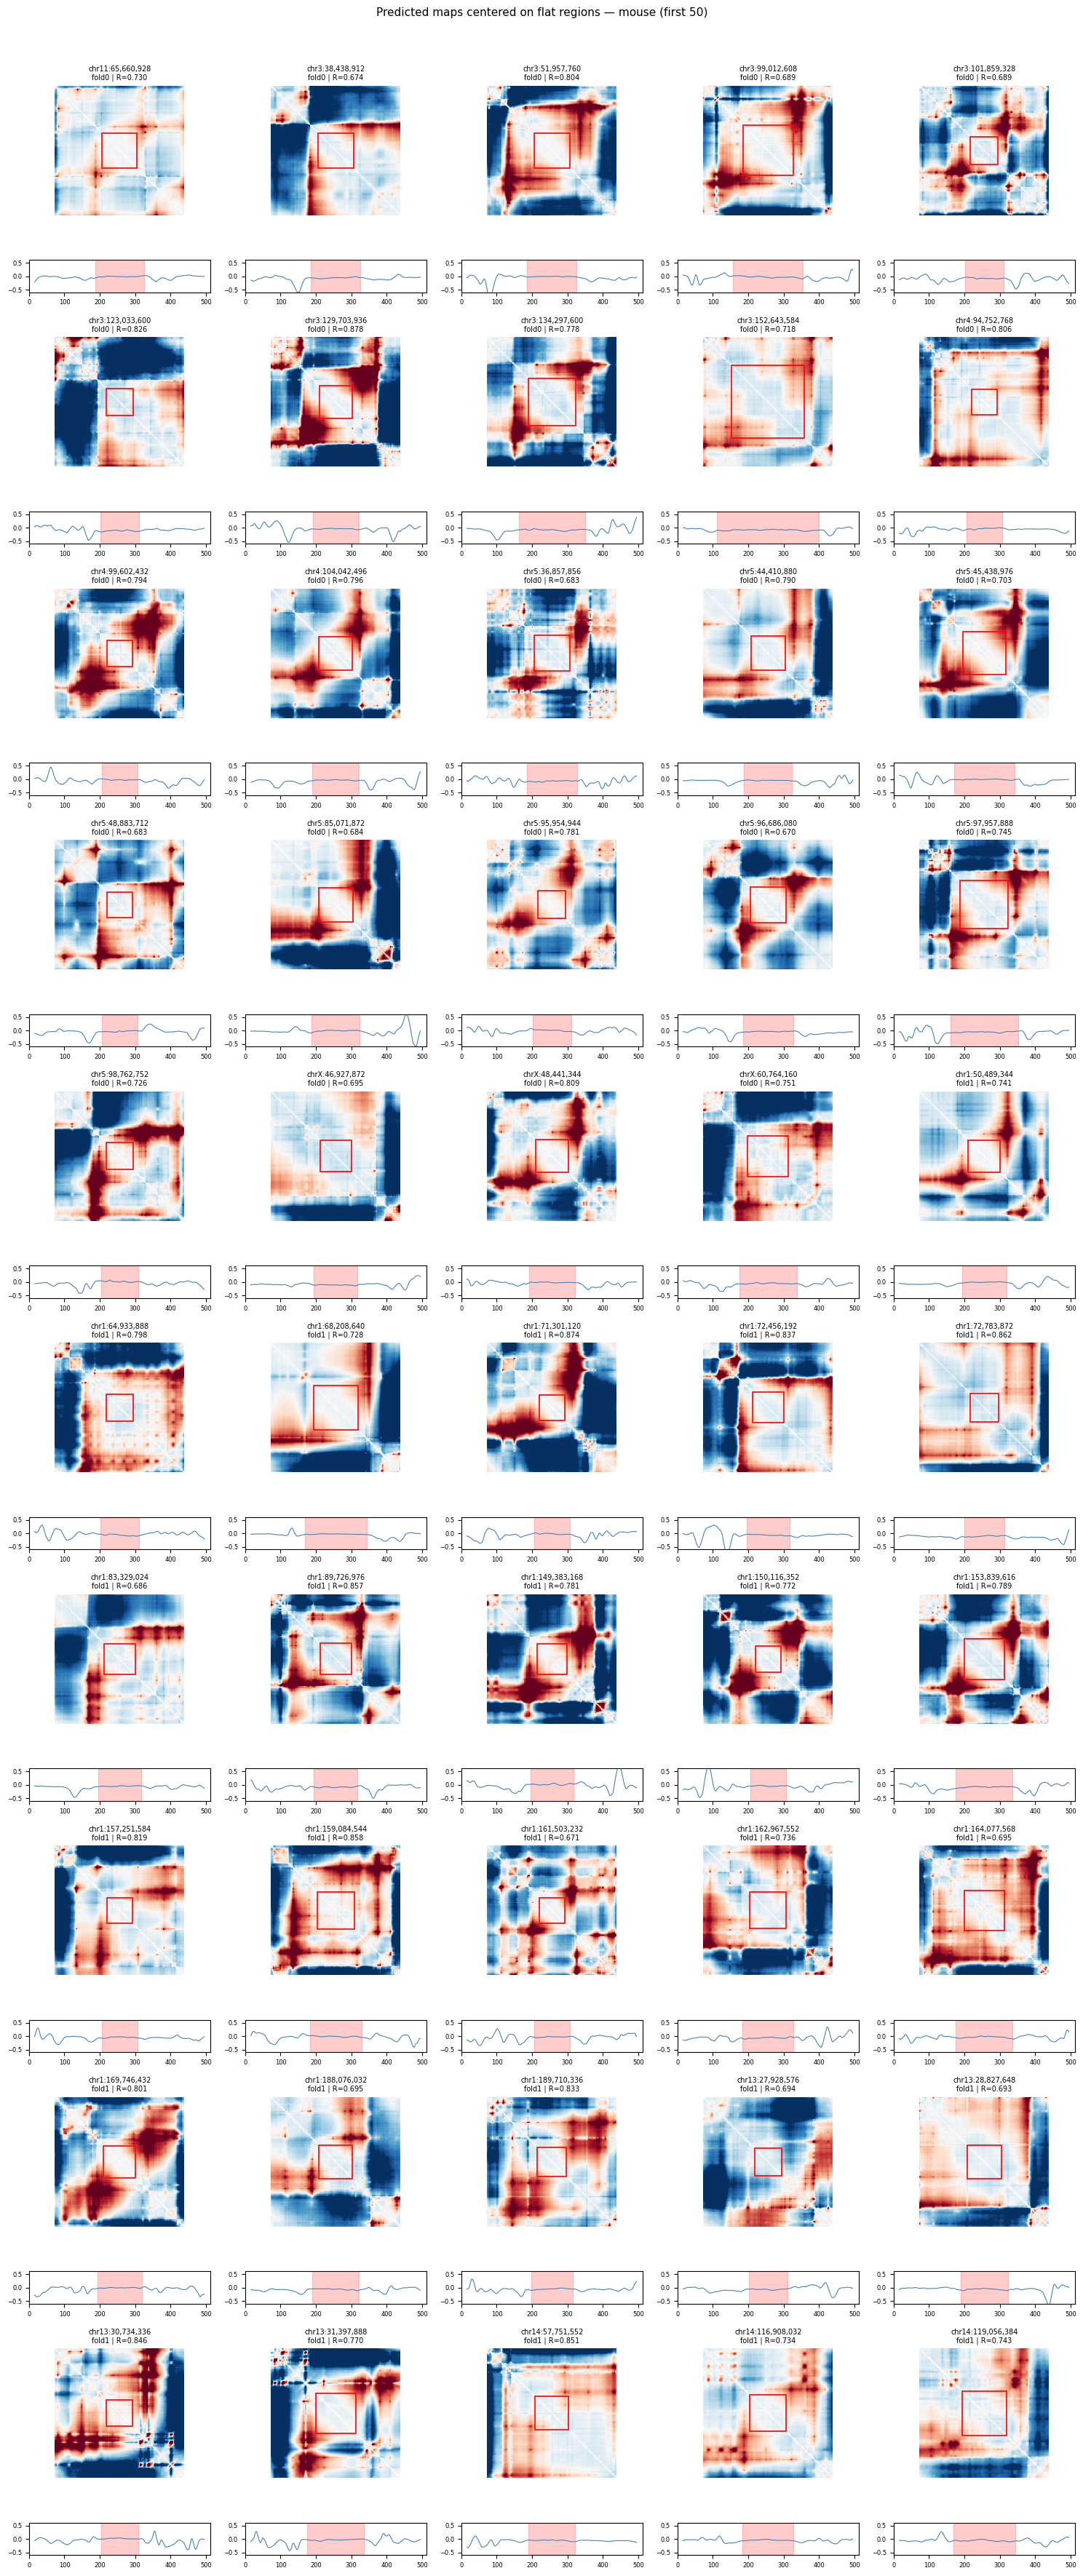

In [9]:
n_cols = 5
n_rows = int(np.ceil(N_PLOT / n_cols))

fig, axes = plt.subplots(
    n_rows * 2, n_cols,
    figsize=(n_cols * 3, n_rows * 3.5),
    gridspec_kw={"height_ratios": [4, 1] * n_rows},
)

for i, (row, pred_mat) in enumerate(zip(flat_df[:N_PLOT].itertuples(), pred_maps)):
    col      = i % n_cols
    row_pair = (i // n_cols) * 2

    ax_map   = axes[row_pair,     col]
    ax_insul = axes[row_pair + 1, col]

    if pred_mat is None:
        ax_map.set_visible(False)
        ax_insul.set_visible(False)
        continue

    title = f"{row.chrom}:{row.centered_start:,}\n{row.fold} | R={row.PearsonR:.3f}"

    plot_pred_with_flat_region(
        ax_map, ax_insul,
        pred_mat,
        row.centered_flat_start,
        row.centered_flat_end,
        title=title,
    )

# Hide unused axes
for j in range(N_PLOT, n_rows * n_cols):
    col      = j % n_cols
    row_pair = (j // n_cols) * 2
    axes[row_pair,     col].set_visible(False)
    axes[row_pair + 1, col].set_visible(False)

plt.suptitle(f"Predicted maps centered on flat regions — {SPECIES} (first {N_PLOT})", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()